# 04b - Segmentación con DeepLabV3+

## Objetivo

Realizar la segmentación semántica de lesiones en mamografías, generando una máscara binaria donde cada píxel se clasifica como lesión o fondo.

## Arquitectura empleada

Se utiliza una arquitectura DeepLabV3+, ampliamente utilizada en tareas de segmentación semántica avanzada, con un encoder ResNet50 preentrenado en ImageNet mediante Transfer Learning.

DeepLabV3+ combina convoluciones atrous (dilatadas) y un módulo ASPP (Atrous Spatial Pyramid Pooling), lo que permite capturar información contextual multiescala y mejorar la detección de estructuras complejas en imágenes médicas. Además, incorpora un decoder que refina los bordes de segmentación y recupera detalles espaciales finos.

El uso de un encoder preentrenado favorece una convergencia más rápida del modelo y mejora la capacidad de generalización, especialmente en conjuntos de datos médicos con tamaño limitado.

## Estrategia de entrenamiento

El entrenamiento se realiza mediante una estrategia de K-Fold Cross Validation con k = 5 folds sobre el conjunto combinado de Train + Validation.

El proceso de entrenamiento se divide en dos fases:

1. Entrenamiento inicial
    - Se congelan parcialmente las capas del encoder.
    - Se entrenan principalmente las capas del decoder, ASPP y segmentación.
2. Fine-tuning
    - Se descongelan más capas del modelo.
    - Se ajustan los pesos globales utilizando una tasa de aprendizaje menor para refinar el rendimiento y mejorar la precisión de segmentación.

## Evaluación final

Tras completar el entrenamiento y seleccionar el mejor modelo, se realiza una evaluación sobre el conjunto de Test, utilizando métricas de segmentación para medir la capacidad del modelo de detectar correctamente las lesiones mamográficas.

### **1. Imports y configuración**

Para desarrollar el modelo de segmentación semántica basado en DeepLabV3+, se utilizan distintas librerías especializadas en procesamiento numérico, manipulación de datos, visión por computador y Deep Learning. Estas herramientas permiten cargar y procesar las mamografías, construir la arquitectura de segmentación, entrenar el modelo y evaluar su rendimiento mediante métricas específicas de segmentación semántica.

Se emplean librerías como NumPy y Pandas para el manejo eficiente de datos y operaciones numéricas, mientras que Matplotlib facilita la visualización de imágenes, máscaras y resultados obtenidos durante el entrenamiento y evaluación del modelo.

Por otro lado, OpenCV y PIL se utilizan para el procesamiento y lectura de imágenes médicas, permitiendo aplicar transformaciones y preparar correctamente tanto las imágenes como las máscaras binarias asociadas.

La implementación del modelo se realiza utilizando PyTorch y Torchvision, aprovechando la arquitectura DeepLabV3+ con encoder ResNet50 preentrenado en ImageNet mediante Transfer Learning. Además, se incorporan herramientas de entrenamiento avanzado como Mixed Precision Training mediante autocast y GradScaler, lo que permite acelerar el entrenamiento y optimizar el uso de memoria en GPU.

Asimismo, se utilizan utilidades de Scikit-Learn para implementar validación cruzada estratificada mediante K-Fold y calcular métricas de evaluación como IoU (Intersection over Union), fundamental en tareas de segmentación semántica.

Finalmente, se establece una semilla aleatoria para garantizar la reproducibilidad de los experimentos y se configura automáticamente el dispositivo de ejecución (CPU o GPU) según la disponibilidad del sistema.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

import cv2
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import jaccard_score

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

Dispositivo: cuda


### **2. Rutas y parámetros**

En esta sección se definen las rutas de trabajo, los directorios de almacenamiento y los principales hiperparámetros utilizados durante el entrenamiento del modelo DeepLabV3+.

Inicialmente se crean directorios destinados a almacenar los modelos entrenados y los resultados generados durante el proceso de segmentación. Posteriormente, las rutas se adaptan específicamente al entorno de Kaggle, plataforma utilizada para ejecutar el entrenamiento del modelo.

La ejecución se realizó en Kaggle debido a las elevadas necesidades computacionales de DeepLabV3+, especialmente al trabajar con imágenes médicas de alta resolución y técnicas de Fine-Tuning sobre modelos preentrenados. Kaggle proporciona acceso gratuito a GPU durante aproximadamente 30 horas semanales, lo que permitió entrenar el modelo de forma eficiente y viable, siendo la alternativa más adecuada para completar el entrenamiento completo del proyecto.

Además, se configuran distintos hiperparámetros fundamentales para el entrenamiento:

-  **IMG_SIZE = 512:** Define el tamaño de entrada de las imágenes, manteniendo coherencia con el preprocesamiento aplicado previamente.
- **BATCH_SIZE = 4:** Se utiliza un tamaño de lote reducido debido al elevado consumo de memoria de DeepLabV3+ durante el entrenamiento en GPU.
- **LR_HEAD = 1e-3:** Utilizado durante la primera fase de entrenamiento, donde se entrenan principalmente las capas ASPP y decoder.
- **LR_FULL = 1e-4:** Utilizado durante el Fine-Tuning completo del modelo, permitiendo ajustes más precisos de los pesos.
- **EPOCHS_PHASE1 = 8:** Fase inicial de calentamiento del decoder y ASPP.
- **EPOCHS_PHASE2 = 15:** Fase de Fine-Tuning completo del modelo.
- **PATIENCE = 5:** Define el criterio de Early Stopping, deteniendo el entrenamiento si el modelo deja de mejorar durante varias épocas consecutivas.
- **N_FOLDS = 5:** Número de particiones empleadas en la validación cruzada K-Fold.

Asimismo, se definen los valores de normalización de ImageNet (IMAGENET_MEAN y IMAGENET_STD), necesarios para adaptar correctamente las imágenes al encoder ResNet50 preentrenado.

Finalmente, se especifican las clases utilizadas en el problema (Normal, Benigno y Maligno), correspondientes a las distintas categorías clínicas presentes en las mamografías del conjunto de datos.

In [2]:
"""

DATA_DIR    = Path('../data')
MODELS_DIR  = Path('../models')
RESULTS_DIR = Path('../results')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)"""

# Rutas adaptadas para Kaggle
DATA_DIR    = Path('/kaggle/input/datasets/mariamestre12546/data-imagenes-segmentacion/data') # Cambia esto por el nombre de tu dataset
MODELS_DIR  = Path('/kaggle/working/models')
RESULTS_DIR = Path('/kaggle/working/results')

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
IMG_SIZE      = 512        # coincide con el preprocesamiento
BATCH_SIZE    = 4         # DeepLabV3+ es pesado en memoria
LR_HEAD       = 1e-3       # fase 1: solo cabeza ASPP + decoder
LR_FULL       = 1e-4       # fase 2: fine-tuning completo
EPOCHS_PHASE1 = 8          # suficiente para calentar ASPP+decoder con CosineAnnealingLR
EPOCHS_PHASE2 = 15         # fine-tuning completo; early stopping corta antes si converge
PATIENCE      = 5
N_FOLDS       = 5

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

CLASS_NAMES   = ['NORM', 'Benigno', 'Maligno']

### **3. Carga de datos desde el preprocesamiento**

La función *build_dataframe()* se encarga de construir un DataFrame estructurado para cada partición del conjunto de datos (train, val o test). Para ello, recorre automáticamente las carpetas de imágenes, máscaras y etiquetas generadas durante el preprocesamiento, recopilando la información necesaria de cada mamografía.

Para cada imagen .png, se obtiene su identificador (image_id) y se buscan tanto la máscara binaria correspondiente como el archivo de etiqueta clínica asociado. Las etiquetas se cargan desde archivos .npy, permitiendo identificar si el caso pertenece a la clase Normal, Benigno o Maligno.

En aquellos casos donde no existe máscara de segmentación,principalmente imágenes clasificadas como NORM, el sistema asigna automáticamente una máscara vacía (completamente negra) durante el entrenamiento. Esto resulta coherente con el problema clínico, ya que dichas imágenes no contienen lesiones visibles. 
Toda esta información se almacena en un DataFrame de Pandas con la siguiente estructura:
- **image_id:** identificador único de la imagen.
- **img_path:** ruta de acceso a la mamografía. 
- **mask_path:** ruta de acceso a la máscara binaria asociada
- **label:** etiqueta clínica del caso 

Posteriormente, se generan los conjuntos df_train, df_val y df_test utilizando dicha función para cada partición del dataset. 
Con el objetivo de aplicar validación curzada K-fold, los conjuntos de entrenamiento y validación de combinan en un único grupo denominado df_trainval. Este conjunto será dividido en 5 folds estratificados durante el entrenamiento. 

In [3]:
def build_dataframe(split: str) -> pd.DataFrame:
    """
    Construye DataFrame {image_id, img_path, mask_path, label} para un split dado.
    Las máscaras binarias (.png) deben estar en DATA_DIR/split/masks/.
    Si no existe máscara para un caso NORM, se genera una máscara negra en tiempo real.
    """
    images_dir = DATA_DIR / split / 'images'
    masks_dir  = DATA_DIR / split / 'masks'
    labels_dir = DATA_DIR / split / 'labels'
    records = []
    for img_path in sorted(images_dir.glob('*.png')):
        img_id     = img_path.stem
        mask_path  = masks_dir / f'{img_id}.png'
        label_file = labels_dir / f'{img_id}_label.npy'
        label      = int(np.load(label_file)) if label_file.exists() else 0
        records.append({
            'image_id':  img_id,
            'img_path':  str(img_path),
            'mask_path': str(mask_path) if mask_path.exists() else None,
            'label':     label
        })
    return pd.DataFrame(records)


df_train = build_dataframe('train')
df_val   = build_dataframe('val')
df_test  = build_dataframe('test')

# Pool train+val para K-Fold
df_trainval = pd.concat([df_train, df_val], ignore_index=True)

print(f'Train+Val: {len(df_trainval)} | Test (fijo): {len(df_test)}')
print('\nDistribución Train+Val:')
print(df_trainval['label'].value_counts().rename(index=dict(enumerate(CLASS_NAMES))))
print('\nDistribución Test:')
print(df_test['label'].value_counts().rename(index=dict(enumerate(CLASS_NAMES))))
print(f"\nCasos con máscara — Train+Val: {df_trainval['mask_path'].notna().sum()} | Test: {df_test['mask_path'].notna().sum()}")

Train+Val: 408 | Test (fijo): 102

Distribución Train+Val:
label
NORM       190
Benigno    115
Maligno    103
Name: count, dtype: int64

Distribución Test:
label
NORM       45
Benigno    31
Maligno    26
Name: count, dtype: int64

Casos con máscara — Train+Val: 408 | Test: 102


Tras cargar correctamente el conjunto de datos, se obtiene un total de 408 imágenes para el conjunto combinado de Train + Validation, mientras que el conjunto de Test queda formado por 102 imágenes. Esta separación permite mantener un conjunto de prueba completamente independiente, garantizando una evaluación final objetiva del modelo una vez concluido el entrenamiento.

En cuanto a la distribución de clases del conjunto Train+Val, se observa un predominio de casos clasificados como NORM con 190 imágenes, seguido de 115 casos benignos y 103 casos malignos. Aunque existe cierto desbalance entre clases, la distribución sigue siendo razonablemente representativa para entrenar el modelo de segmentación semántica.

Por otro lado, el conjunto de Test mantiene una distribución similar, con 45 casos normales, 31 benignos y 26 malignos. Mantener proporciones parecidas entre entrenamiento y prueba resulta importante para asegurar que la evaluación final refleje adecuadamente la capacidad de generalización del modelo sobre datos no vistos previamente.

Asimismo, se verifica que todas las imágenes disponen correctamente de una máscara asociada dentro de la estructura del dataset, contabilizando 408 máscaras en Train+Val y 102 máscaras en Test. En los casos normales (NORM), las máscaras corresponden a imágenes completamente negras, representando correctamente la ausencia de lesiones mamográficas.

Estas comprobaciones iniciales permiten validar tanto la integridad del conjunto de datos como la correcta organización de las imágenes, etiquetas y máscaras antes de comenzar el entrenamiento del modelo DeepLabV3+.

### **4. Dataset y Transforms**

En esta sección se implementa una clase personalizada denominada SegmentationDataset, encargada de cargar y preparar las mamografías y sus máscaras binarias para el entrenamiento del modelo DeepLabV3+. Esta clase hereda de Dataset de PyTorch, lo que permite integrar fácilmente los datos dentro del flujo de entrenamiento mediante DataLoader.

Cada imagen se carga inicialmente en escala de grises utilizando OpenCV. Posteriormente, debido a que el encoder ResNet50 preentrenado en ImageNet espera imágenes de tres canales, la imagen se transforma replicando el canal de grises tres veces para generar una representación RGB artificial. Después, las imágenes se normalizan utilizando los valores estándar de ImageNet (mean y std), garantizando compatibilidad con el modelo preentrenado.

Por otro lado, las máscaras de segmentación se cargan como imágenes binarias donde:
- **0** representa fondo 
- **1** representa lesión

En los casos donde no exite máscara asociada, principalmente imágenes normales, el sistema genera tuomáticamente una máscara completamente negra, indicando ausencia de lesión. Admeás, se implmenta un sistema de DataAugmentation geométrica aplicado de forma sincronizada tanto a la imagen como a su máscara correspondiente. Estas transformaciones incluyen tanto a la imagen como a su máscara correspondiente. Estas tranformaciones incluyen flip horizontal, flip verticas y rotaciones aletorais entre -15 y 15.

Aplicar las transformaciones de manera sincronizada resulta fundamental en segmentación semántica, ya que cualquier modificación realizada sobre la imagen debe mantenerse alineada con la máscara binaria para preservar correctamente la localización de las lesiones.

Finalmente, se crean los DataLoaders para entrenamiento, validación y test. Estos objetos permiten cargar los datos en mini-batches de forma eficiente durante el entrenamiento del modelo, optimizando el uso de memoria y acelerando el procesamiento en GPU.

El conjunto de entrenamiento utiliza shuffle=True y augmentación activada para mejorar la capacidad de generalización del modelo, mientras que los conjuntos de validación y test se cargan sin augmentación y manteniendo el orden original de las imágenes para garantizar una evaluación consistente y reproducible.


In [4]:
class SegmentationDataset(Dataset):
    """
    Dataset de mamografías para segmentación binaria (lesión vs fondo).
    - Imagen: escala de grises → 3 canales → normalización ImageNet.
    - Máscara: binaria (0/1), sin normalización.
    - Augmentation: flip horizontal + rotación aplicados SINCRÓNICAMENTE a imagen y máscara.
    - Los casos NORM sin máscara reciben una máscara negra (todo ceros).
    """
    def __init__(self, dataframe: pd.DataFrame, augment: bool = False):
        self.df      = dataframe.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def _load_image(self, path: str) -> np.ndarray:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None: 
            raise FileNotFoundError(f"Imagen no encontrada: {path}")
        return img

    def _load_mask(self, path) -> np.ndarray:
        if path is None:
            return np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            return np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        return (mask > 127).astype(np.uint8)  # binarización robusta

    def _augment(self, img: np.ndarray, mask: np.ndarray):
        """Augmentation geométrico sincronizado imagen + máscara."""
        if np.random.rand() > 0.5:
            img  = cv2.flip(img, 1)
            mask = cv2.flip(mask, 1)
        # añadido despues
        if np.random.rand() > 0.7:
            img  = cv2.flip(img, 0)
            mask = cv2.flip(mask, 0)
        angle = np.random.uniform(-15, 15)
        M     = cv2.getRotationMatrix2D((IMG_SIZE // 2, IMG_SIZE // 2), angle, 1.0)
        img   = cv2.warpAffine(img,  M, (IMG_SIZE, IMG_SIZE), flags=cv2.INTER_LINEAR)
        mask  = cv2.warpAffine(mask, M, (IMG_SIZE, IMG_SIZE), flags=cv2.INTER_NEAREST)
        return img, mask

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = self._load_image(row['img_path'])
        mask = self._load_mask(row['mask_path'])

        if self.augment:
            img, mask = self._augment(img, mask)

        # Imagen → 3 canales → tensor normalizado
        img_rgb = np.stack([img, img, img], axis=2).astype(np.float32) / 255.0
        mean    = np.array(IMAGENET_MEAN, dtype=np.float32)
        std     = np.array(IMAGENET_STD,  dtype=np.float32)
        img_rgb = (img_rgb - mean) / std
        img_t   = torch.from_numpy(img_rgb.transpose(2, 0, 1))  # (3, H, W)

        # Máscara → tensor float (1, H, W) para BCEWithLogitsLoss
        mask_t = torch.from_numpy(mask.astype(np.float32)).unsqueeze(0)  # (1, H, W)

        return img_t, mask_t


def make_loaders(df_tr: pd.DataFrame, df_vl: pd.DataFrame):
    """Crea DataLoaders para un par train/val."""
    tr = DataLoader(SegmentationDataset(df_tr, augment=True),
                    batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    vl = DataLoader(SegmentationDataset(df_vl, augment=False),
                    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    return tr, vl


# DataLoader de test — se usa solo en la evaluación final
test_loader = DataLoader(
    SegmentationDataset(df_test, augment=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

### **5. Arquitectura — DeepLabV3+ con encoder ResNet50**

Para la tarea de segmentación semántica se implementa una arquitectura DeepLabV3+ utilizando un encoder ResNet50 preentrenado en ImageNet mediante Transfer Learning. Esta arquitectura destaca por su capacidad para capturar información contextual multiescala y generar segmentaciones más precisas, especialmente en imágenes médicas donde las lesiones pueden presentar tamaños, formas y contrastes muy variables.

El backbone ResNet50 se modifica utilizando convoluciones dilatadas (dilated convolutions), permitiendo mantener una mayor resolución espacial en los mapas de características sin incrementar excesivamente el coste computacional. Gracias a ello, el modelo conserva mejor la información estructural de las lesiones mamográficas durante el proceso de extracción de características profundas.

Uno de los componentes principales de DeepLabV3+ es el módulo ASPP (Atrous Spatial Pyramid Pooling). Este bloque aplica múltiples convoluciones dilatadas con diferentes tasas de dilatación (6, 12 y 18) sobre las features profundas generadas por el encoder. De esta forma, el modelo es capaz de capturar contexto a distintas escalas simultáneamente, mejorando la detección tanto de lesiones pequeñas como de regiones tumorales más extensas.

Además, el ASPP incorpora una rama de Global Average Pooling, que permite extraer información contextual global de toda la imagen mamográfica. Posteriormente, todas las representaciones obtenidas se concatenan y proyectan en un único mapa de características enriquecido.

Tras el bloque ASPP, la arquitectura incorpora un decoder ligero encargado de refinar la segmentación final. Para ello, se combinan las features profundas obtenidas por ASPP (resolución H/16) con características de bajo nivel extraídas de capas tempranas del encoder (resolución H/4) mediante una skip connection. Esta combinación resulta especialmente útil para recuperar detalles espaciales finos y mejorar la precisión de los bordes de las lesiones segmentadas.

Finalmente, el decoder realiza una interpolación progresiva hasta recuperar la resolución original de entrada (512×512) y genera una máscara binaria de salida con un único canal, donde cada píxel representa la probabilidad de pertenecer a lesión o fondo.

El entrenamiento del modelo se realiza mediante una estrategia de Fine-Tuning en dos fases:

- **Fase 1 — Entrenamiento inicial**
    - El encoder ResNet50 permanece congelado.
    - Se entrenan únicamente las capas ASPP y decoder.
    - Esta etapa permite adaptar rápidamente la cabeza de segmentación al dominio mamográfico.
- **Fase 2 — Fine-Tuning completo**
    - Se descongelan progresivamente las capas del encoder.
    - Se entrena toda la red con una tasa de aprendizaje menor.
    - El objetivo es ajustar las características profundas aprendidas en ImageNet a las particularidades de las mamografías.

Finalmente, se realiza una comprobación de dimensiones utilizando tensores aleatorios para verificar que la arquitectura produce correctamente máscaras de salida con tamaño [batch_size, 1, 512, 512], asegurando compatibilidad con el problema de segmentación binaria planteado.

In [5]:
from torchvision.models._utils import IntermediateLayerGetter

class ASPPConv(nn.Module):
    """Convolución dilatada con BN + ReLU para ASPP."""
    def __init__(self, in_ch: int, out_ch: int, dilation: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=dilation, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class ASPPPooling(nn.Module):
    """Pooling global + proyección para capturar contexto de imagen completa."""
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        size = x.shape[2:]
        out  = self.block(x)
        return F.interpolate(out, size=size, mode='bilinear', align_corners=False)


class ASPP(nn.Module):
    """
    Atrous Spatial Pyramid Pooling.
    Combina: conv 1×1 + 3 conv dilatadas (r=6,12,18) + global pooling → concat → proyección.
    """
    def __init__(self, in_ch: int = 2048, out_ch: int = 256,
                 dilations: tuple = (6, 12, 18)):
        super().__init__()
        self.conv1   = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
        self.atrous6  = ASPPConv(in_ch, out_ch, dilations[0])
        self.atrous12 = ASPPConv(in_ch, out_ch, dilations[1])
        self.atrous18 = ASPPConv(in_ch, out_ch, dilations[2])
        self.pool     = ASPPPooling(in_ch, out_ch)

        self.project  = nn.Sequential(
            nn.Conv2d(out_ch * 5, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )

    def forward(self, x):
        feats = [
            self.conv1(x),
            self.atrous6(x),
            self.atrous12(x),
            self.atrous18(x),
            self.pool(x)
        ]
        return self.project(torch.cat(feats, dim=1))


class DeepLabV3Plus(nn.Module):
    def __init__(self, freeze_encoder: bool = True):
        super().__init__()
        # Usar la función oficial de PyTorch para reemplazar el backbone 
        # con dilatación (output_stride = 16)
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1, replace_stride_with_dilation=[False, False, True])
        
        # Extraemos las capas que necesitamos limpiamente
        return_layers = {'layer1': 'low_level', 'layer4': 'high_level'}
        self.backbone = IntermediateLayerGetter(resnet, return_layers=return_layers)

        if freeze_encoder:
            for p in self.backbone.parameters():
                p.requires_grad = False

        # ---- ASPP ----
        self.aspp = ASPP(in_ch=2048, out_ch=256)

        # ---- Decoder ----
        self.low_proj = nn.Sequential(
            nn.Conv2d(256, 48, 1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True)
        )
        self.decoder_conv = nn.Sequential(
            nn.Conv2d(256 + 48, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )
        self.head = nn.Conv2d(256, 1, 1)

    def forward(self, x):
        h, w = x.shape[2:]

        # Encoder (IntermediateLayerGetter nos da un diccionario)
        features = self.backbone(x)
        low  = features['low_level']   # (B, 256, H/4, W/4)
        high = features['high_level']  # (B, 2048, H/16, W/16)

        # ASPP
        aspp_out = self.aspp(high)

        # Decoder
        aspp_up = F.interpolate(aspp_out, size=low.shape[2:],
                                mode='bilinear', align_corners=False)
        low_proj = self.low_proj(low)
        
        dec = self.decoder_conv(torch.cat([aspp_up, low_proj], dim=1))
        dec = F.interpolate(dec, size=(h, w), mode='bilinear', align_corners=False)
        
        return self.head(dec)


def build_deeplab(freeze_encoder: bool = True) -> nn.Module:
    return DeepLabV3Plus(freeze_encoder=freeze_encoder)


# Comprobación rápida de dimensiones
_model = build_deeplab().to(DEVICE)
_x     = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    _out = _model(_x)
print(f'Input:  {_x.shape}  →  Output: {_out.shape}  (esperado: [2, 1, {IMG_SIZE}, {IMG_SIZE}])')
del _model, _x, _out

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]


Input:  torch.Size([2, 3, 512, 512])  →  Output: torch.Size([2, 1, 512, 512])  (esperado: [2, 1, 512, 512])


### **6. Función de pérdida - Dice + BCE combinadas**

Para entrenar el modelo se utiliza una función de pérdida combinada denominada Dice + BCE Loss, ampliamente empleada en segmentación médica debido al fuerte desbalance entre fondo y lesión presente en este tipo de imágenes.

La componente Binary Cross-Entropy (BCE) evalúa cada píxel de manera independiente, penalizando las diferencias entre la predicción y la máscara real. Además, se incorpora un parámetro pos_weight para dar mayor importancia a los píxeles pertenecientes a lesión, reduciendo así el impacto del desequilibrio entre clases.

Por otro lado, la Dice Loss mide directamente el grado de solapamiento entre la máscara predicha y la máscara real. Esta métrica resulta especialmente útil en mamografías, donde las lesiones suelen ocupar regiones pequeñas frente al gran predominio de fondo.

La pérdida final combina ambas contribuciones mediante un factor alpha, equilibrando precisión pixel a pixel y calidad global de segmentación.

Además, se implementa el cálculo del Dice Coefficient como métrica de evaluación. Esta métrica permite cuantificar la similitud entre las máscaras predichas y las reales, tomando valores entre 0 y 1, donde valores cercanos a 1 indican una segmentación más precisa.

In [6]:
class DiceBCELoss(nn.Module):
    """
    Pérdida combinada: Dice Loss + BCE con logits.
    pos_weight penaliza más los falsos negativos en lesiones pequeñas
    (el fondo domina ampliamente en mamografías).
    """
    def __init__(self, alpha: float = 0.5, smooth: float = 1.0, pos_weight: float = 3.0):
        super().__init__()
        self.alpha  = alpha
        self.smooth = smooth
        # pos_weight se mueve al device en forward para compatibilidad CPU/GPU
        self.register_buffer('pw', torch.tensor([pos_weight]))

    def dice_loss(self, logits, targets):
        probs = torch.sigmoid(logits)
        inter = (probs * targets).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice  = (2.0 * inter + self.smooth) / (union + self.smooth)
        return 1.0 - dice.mean()

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pw
        )
        return self.alpha * self.dice_loss(logits, targets) + (1 - self.alpha) * bce


def dice_coefficient(preds_bin: np.ndarray, targets: np.ndarray, smooth: float = 1.0) -> float:
    """Dice coefficient (métrica, no pérdida) sobre arrays binarios numpy."""
    inter = (preds_bin * targets).sum()
    return (2.0 * inter + smooth) / (preds_bin.sum() + targets.sum() + smooth)


criterion_seg = DiceBCELoss(alpha=0.5, pos_weight=3.0).to(DEVICE)

### **7. Funciones de entrenamiento y evaluación**

En esta sección se implementan las funciones encargadas del entrenamiento y evaluación del modelo DeepLabV3+. Durante el entrenamiento, el modelo procesa las imágenes por mini-batches, calcula la pérdida mediante la función Dice + BCE Loss y actualiza los pesos utilizando backpropagation.

Además, se utiliza Mixed Precision Training mediante autocast y GradScaler, permitiendo acelerar el entrenamiento y reducir el consumo de memoria GPU sin perder estabilidad numérica. Esto resulta especialmente útil al trabajar con arquitecturas pesadas como DeepLabV3+ y mamografías de alta resolución.

Durante cada época también se calcula el Dice Coefficient sobre las predicciones binarias generadas por el modelo, permitiendo monitorizar la calidad de segmentación tanto en entrenamiento como en validación.

La función evaluate() se encarga de evaluar el modelo sobre el conjunto de validación o test sin actualizar pesos. Además de la pérdida, calcula métricas de segmentación como Dice Coefficient o IoU (Intersection over Union). Estas métricas permiten medir el grado de solapamiento entre las máscaras predichas y las máscaras reales.

Por otro lado, se implementa un mecanismo de Early Stopping basado en val_dice. En segmentación médica, la pérdida puede estabilizarse mientras la calidad de segmentación sigue mejorando, por lo que monitorizar el Dice suele resultar más fiable que utilizar únicamente la loss. Si el Dice de validación no mejora durante varias épocas consecutivas (patience), el entrenamiento se detiene automáticamente para evitar sobreajuste.

Finalmente, el entrenamiento de cada fase utiliza un scheduler CosineAnnealingLR, que reduce progresivamente la tasa de aprendizaje siguiendo una curva cosenoidal. Esta estrategia favorece una convergencia más estable y ayuda a mejorar el ajuste fino del modelo durante el entrenamiento.

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_dice = 0.0
    n_samples  = 0
    for imgs, masks in tqdm(loader, desc='  train', leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        with autocast():
            logits = model(imgs)
            loss   = criterion(logits, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            preds_bin = (torch.sigmoid(logits) > 0.5).float()
            inter = (preds_bin * masks).sum()
            dice  = (2 * inter + 1) / (preds_bin.sum() + masks.sum() + 1)
            total_dice += dice.item() * imgs.size(0)

        total_loss += loss.item() * imgs.size(0)
        n_samples  += imgs.size(0)

    return total_loss / n_samples, total_dice / n_samples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_masks = [], []
    n_samples = 0

    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        loss   = criterion(logits, masks)
        total_loss += loss.item() * imgs.size(0)
        n_samples  += imgs.size(0)

        preds_bin = (torch.sigmoid(logits) > 0.5).cpu().numpy().astype(np.uint8)
        masks_np  = masks.cpu().numpy().astype(np.uint8)
        all_preds.append(preds_bin)
        all_masks.append(masks_np)

    all_preds = np.concatenate(all_preds, axis=0)  # (N, 1, H, W)
    all_masks = np.concatenate(all_masks, axis=0)

    dice = dice_coefficient(all_preds.flatten(), all_masks.flatten())
    iou  = jaccard_score(all_masks.flatten(), all_preds.flatten(), zero_division=1)

    return total_loss / n_samples, dice, iou, all_preds, all_masks


class EarlyStopping:
    """
    Monitoriza val_dice (maximizar) en lugar de val_loss.
    En segmentación médica con clases desequilibradas, la loss puede
    estancarse mientras el Dice sigue mejorando — monitorizar el Dice
    evita parar demasiado pronto.
    """
    def __init__(self, patience: int, path: str):
        self.patience  = patience
        self.path      = path
        self.best_dice = -np.inf
        self.counter   = 0
        self.stop      = False

    def __call__(self, val_dice: float, model: nn.Module):
        if val_dice > self.best_dice:
            self.best_dice = val_dice
            torch.save(model.state_dict(), self.path)
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def run_phase(model, train_loader, val_loader, optimizer, criterion,
              n_epochs, device, ckpt_path, patience=PATIENCE):
    """
    Entrena una fase con CosineAnnealingLR + EarlyStopping por val_dice.
    CosineAnnealingLR decae el LR suavemente hasta eta_min en T_max épocas,
    lo que acelera la convergencia y evita oscilaciones del ReduceLROnPlateau.
    """
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=1e-6
    )
    early_stop = EarlyStopping(patience=patience, path=ckpt_path)
    history    = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': []}

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_dice              = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_dice, vl_iou, *_ = evaluate(model, val_loader, criterion, device)
        scheduler.step()
        early_stop(vl_dice, model)   # ✅ monitorizar Dice, no loss
        history['train_loss'].append(tr_loss);  history['val_loss'].append(vl_loss)
        history['train_dice'].append(tr_dice);  history['val_dice'].append(vl_dice)
        print(f'  Epoch {epoch:3d}/{n_epochs} | '
              f'Train {tr_loss:.4f}/{tr_dice:.4f} | '
              f'Val {vl_loss:.4f}/{vl_dice:.4f} (IoU {vl_iou:.4f})')
        if early_stop.stop:
            print(f'  Early stopping en época {epoch} (mejor Dice val: {early_stop.best_dice:.4f})')
            break

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return history

### **8. K-Fold Cross Validation (k=5) sobre Train+Val**

El entrenamiento del modelo se realiza utilizando una estrategia de K-Fold Cross Validation con k = 5. Para ello, el conjunto combinado Train + Validation se divide en cinco particiones estratificadas, manteniendo una distribución equilibrada de las clases (Normal, Benigno y Maligno) en cada fold.

En cada iteración, cuatro folds se utilizan para entrenamiento y uno para validación, permitiendo entrenar y evaluar el modelo cinco veces sobre diferentes subconjuntos de datos. Esta estrategia proporciona una estimación más robusta y fiable del rendimiento del modelo, especialmente en datasets médicos de tamaño reducido.

Para cada fold se generan automáticamente los DataLoaders de entrenamiento y validación, aplicando augmentación únicamente sobre el conjunto de entrenamiento.

In [8]:
skf          = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
X            = df_trainval['img_path'].values
y            = df_trainval['label'].values

fold_results   = []   # métricas de validación por fold
fold_histories = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f'\n{"="*60}')
    print(f'  FOLD {fold}/{N_FOLDS}  |  train: {len(train_idx)}  val: {len(val_idx)}')
    print(f'{"="*60}')

    df_tr = df_trainval.iloc[train_idx].reset_index(drop=True)
    df_vl = df_trainval.iloc[val_idx].reset_index(drop=True)
    train_loader, val_loader = make_loaders(df_tr, df_vl)

    # --- Fase 1: solo ASPP + decoder (encoder congelado) ---
    model = build_deeplab(freeze_encoder=True).to(DEVICE)
    head_params = [p for p in model.parameters() if p.requires_grad]
    opt1 = optim.Adam(head_params, lr=LR_HEAD)
    print('  Fase 1 — ASPP + decoder (encoder congelado)')
    h1 = run_phase(model, train_loader, val_loader, opt1, criterion_seg,
                   EPOCHS_PHASE1, DEVICE, str(MODELS_DIR / f'deeplab_fold{fold}_phase1.pt'))

    # --- Fase 2: fine-tuning completo ---
    for p in model.parameters():
        p.requires_grad = True
    opt2 = optim.Adam(model.parameters(), lr=LR_FULL, weight_decay=1e-4)
    print('  Fase 2 — fine-tuning completo')
    h2 = run_phase(model, train_loader, val_loader, opt2, criterion_seg,
                   EPOCHS_PHASE2, DEVICE, str(MODELS_DIR / f'deeplab_fold{fold}_best.pt'))

    # Evaluar fold en validación
    _, val_dice, val_iou, _, _ = evaluate(model, val_loader, criterion_seg, DEVICE)

    fold_results.append({'fold': fold, 'val_dice': val_dice, 'val_iou': val_iou})
    fold_histories.append((h1, h2))
    print(f'  Fold {fold} → Val Dice: {val_dice:.4f} | Val IoU: {val_iou:.4f}')

print('\nResumen K-Fold:')
df_kfold = pd.DataFrame(fold_results)
print(df_kfold.to_string(index=False))
print(f"\nMedia Val Dice: {df_kfold['val_dice'].mean():.4f} ± {df_kfold['val_dice'].std():.4f}")
print(f"Media Val IoU:  {df_kfold['val_iou'].mean():.4f} ± {df_kfold['val_iou'].std():.4f}")


  FOLD 1/5  |  train: 326  val: 82
  Fase 1 — ASPP + decoder (encoder congelado)


  Epoch   1/8 | Train 0.5646/0.1755 | Val 0.5235/0.1667 (IoU 0.0909)


  Epoch   2/8 | Train 0.4456/0.3404 | Val 0.4192/0.4363 (IoU 0.2790)


  Epoch   3/8 | Train 0.4276/0.3492 | Val 0.4203/0.4885 (IoU 0.3232)


  Epoch   4/8 | Train 0.4238/0.3757 | Val 0.4214/0.3817 (IoU 0.2358)


...

  Epoch   7/15 | Train 0.3598/0.5372 | Val 0.3975/0.6012 (IoU 0.4298)


  Epoch   8/15 | Train 0.3459/0.5329 | Val 0.3962/0.5519 (IoU 0.3811)


  Epoch   9/15 | Train 0.3048/0.5974 | Val 0.3506/0.5273 (IoU 0.3580)


  Epoch  10/15 | Train 0.3024/0.5428 | Val 0.3805/0.4393 (IoU 0.2815)


  Epoch  11/15 | Train 0.2952/0.5134 | Val 0.3191/0.5759 (IoU 0.4044)
  Early stopping en época 11 (mejor Dice val: 0.6896)
  Fold 5 → Val Dice: 0.6896 | Val IoU: 0.5263

Resumen K-Fold:
 fold  val_dice  val_iou
    1  0.681118 0.516435
    2  0.616839 0.445962
    3  0.628218 0.457956
    4  0.708736 0.548869
    5  0.689649 0.526308

Media Val Dice: 0.6649 ± 0.0402
Media Val IoU:  0.4991 ± 0.0448


El entrenamiento mediante validación cruzada K-Fold permitió evaluar el comportamiento del modelo DeepLabV3+ sobre diferentes particiones del conjunto de datos, proporcionando una estimación más robusta de su capacidad de generalización.

En términos generales, se observa una evolución positiva del modelo a lo largo de las dos fases de entrenamiento. Durante la Fase 1, donde únicamente se entrenan las capas ASPP y decoder con el encoder congelado, el modelo comienza a aprender la localización básica de las lesiones, obteniendo mejoras progresivas en las métricas Dice e IoU.

Sin embargo, es durante la Fase 2 de Fine-Tuning completo cuando se producen las mejoras más significativas. Al descongelar el encoder ResNet50 y ajustar toda la red con una tasa de aprendizaje menor, el modelo logra adaptarse mejor al dominio mamográfico, aumentando considerablemente la calidad de segmentación.

Los resultados obtenidos muestran valores de Dice Coefficient comprendidos entre aproximadamente 0.62 y 0.71 según el fold evaluado, mientras que el IoU alcanza valores cercanos a 0.55 en los mejores casos. El mejor rendimiento se obtiene en el Fold 4, con:
- **Dice: 0.7087**
- **IoU: 0.5489**

Por otro lado, el fold con menor rendimiento corresonde al Fold 2, aunque mantiene resultados razonablemente consistentes: 
- **Dice = 0.6168**
- **ioU = 0.4460** 

La media global obtenida tras los cinco folds es: 
- **Dice medio: 0.6649 ± 0.0402**
- **IoU medio: 0.4991 ± 0.0448**

Estos resultados indican que el modelo consigue un grado de solapamiento moderadamente alto entre las máscaras predichas y las máscaras reales, demostrando una capacidad adecuada para detectar y segmentar lesiones mamográficas.

Además, la desviación estándar relativamente baja entre folds sugiere que el comportamiento del modelo es estable y consistente frente a diferentes particiones del dataset, lo cual resulta especialmente importante en problemas médicos donde la variabilidad de los datos puede afectar significativamente al rendimiento.

También puede observarse el efecto positivo del mecanismo de Early Stopping, que detiene automáticamente el entrenamiento cuando las métricas de validación dejan de mejorar. Esto ayuda a evitar sobreajuste y permite conservar los pesos correspondientes al mejor rendimiento obtenido en cada fold.

En conjunto, los resultados muestran que la arquitectura DeepLabV3+ con encoder ResNet50 y entrenamiento en dos fases logra aprender representaciones útiles para la segmentación semántica de lesiones en mamografías, obteniendo métricas competitivas y un comportamiento estable durante la validación cruzada.


### **9. Curvas de entrenamiento**

Para analizar la evolución del modelo durante el entrenamiento, se representan gráficamente las curvas de Loss y Dice Coefficient para cada uno de los folds del proceso K-Fold.

En cada gráfica se comparan las métricas de entrenamiento y validación a lo largo de las épocas, permitiendo observar el comportamiento del modelo, su capacidad de aprendizaje y posibles signos de sobreajuste.

Además, se incluye una línea vertical discontinua que indica el final de la Fase 1 y el inicio del Fine-Tuning completo, facilitando la visualización del impacto que tiene el desbloqueo del encoder ResNet50 sobre la evolución de las métricas.

Estas gráficas permiten verificar que el modelo converge de forma estable y que, en general, las métricas de validación mejoran tras la segunda fase de entrenamiento, confirmando la utilidad de la estrategia de Fine-Tuning empleada.

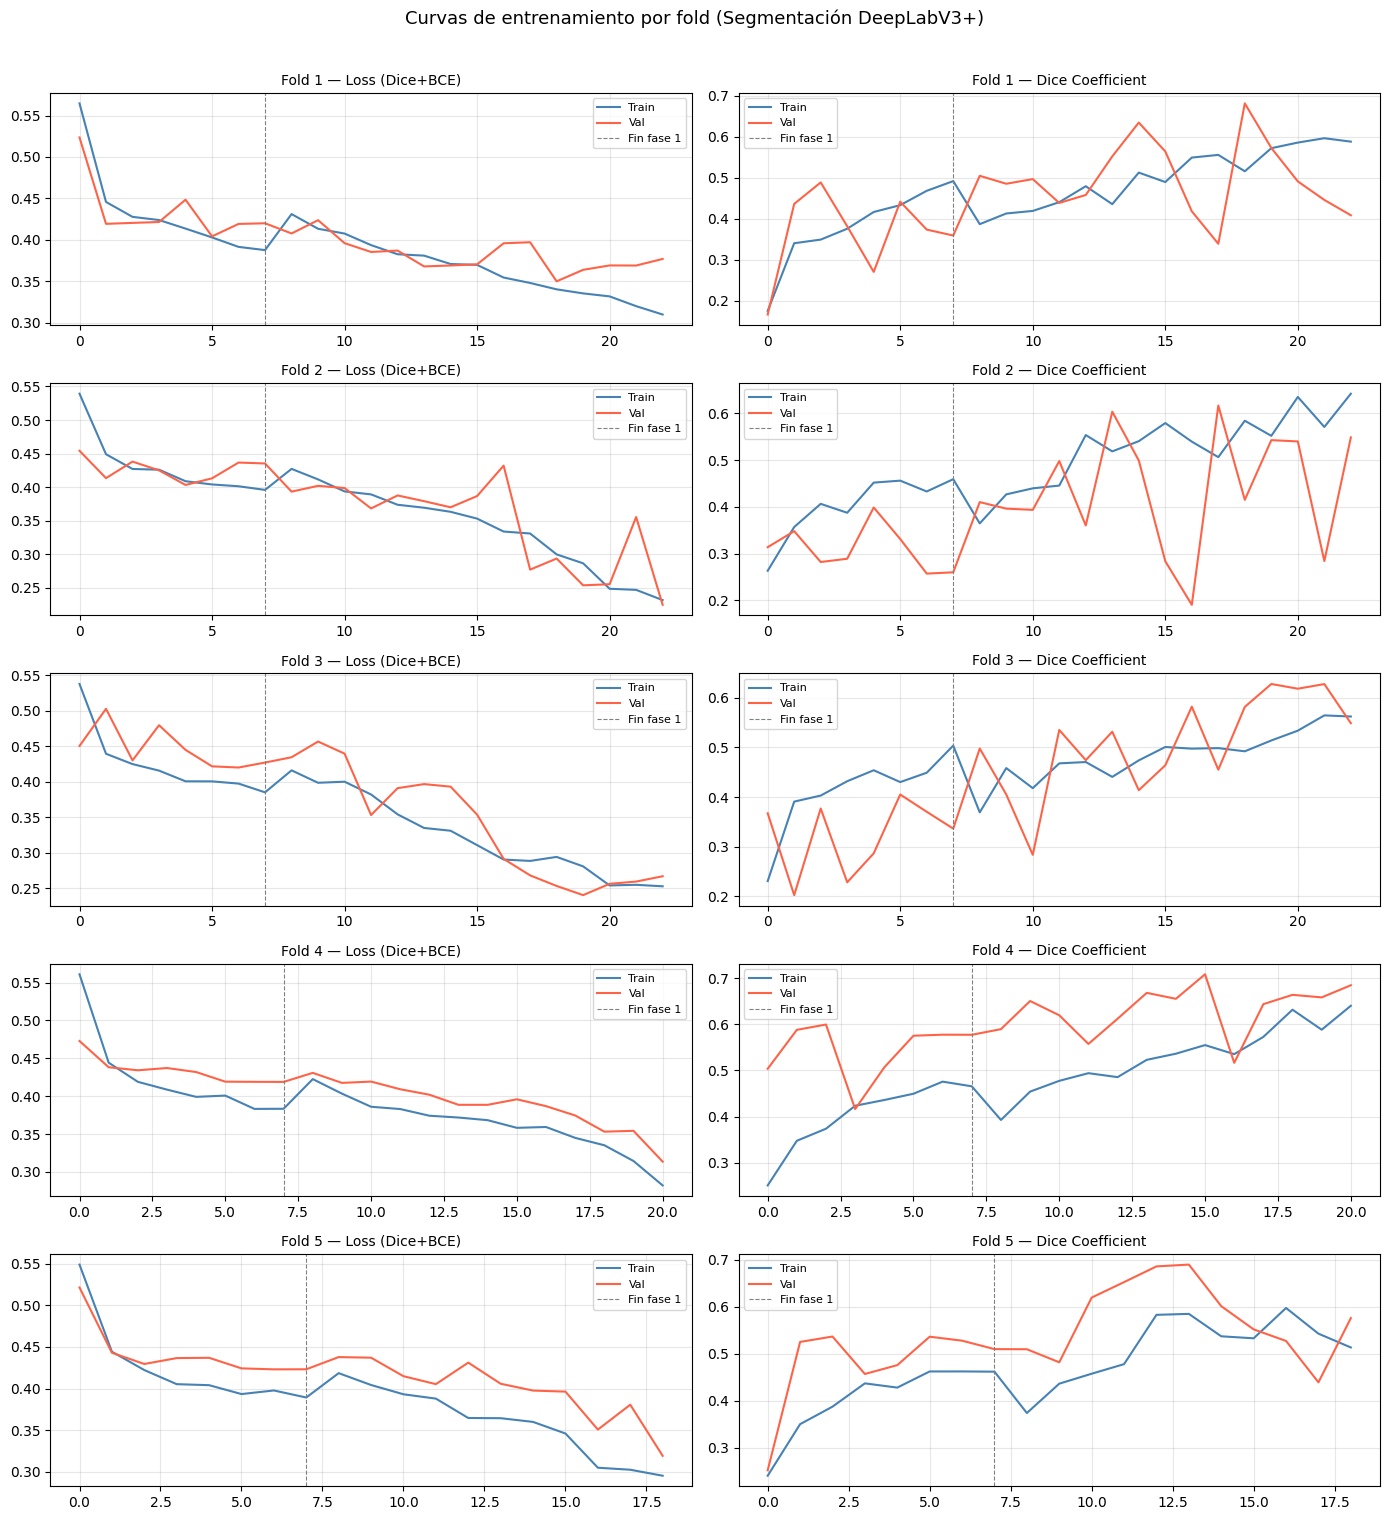

In [9]:
fig, axes = plt.subplots(N_FOLDS, 2, figsize=(14, N_FOLDS * 3))

for fold_idx, (h1, h2) in enumerate(fold_histories):
    tr_loss = h1['train_loss'] + h2['train_loss']
    vl_loss = h1['val_loss']   + h2['val_loss']
    tr_dice = h1['train_dice'] + h2['train_dice']
    vl_dice = h1['val_dice']   + h2['val_dice']
    pb      = len(h1['train_loss'])   # boundary entre fases

    for ax, (tr, vl), ylabel in zip(
        axes[fold_idx],
        [(tr_loss, vl_loss), (tr_dice, vl_dice)],
        ['Loss (Dice+BCE)', 'Dice Coefficient']
    ):
        ax.plot(tr, label='Train', color='steelblue')
        ax.plot(vl, label='Val',   color='tomato')
        ax.axvline(pb - 1, color='gray', linestyle='--', linewidth=0.8, label='Fin fase 1')
        ax.set_title(f'Fold {fold_idx+1} — {ylabel}', fontsize=10)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Curvas de entrenamiento por fold (Segmentación DeepLabV3+)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Las curvas de entrenamiento muestran una evolución coherente del modelo DeepLabV3+ a lo largo de los cinco folds del proceso K-Fold. En general, puede observarse una disminución progresiva de la función de pérdida (Dice + BCE Loss) tanto en entrenamiento como en validación, indicando que el modelo aprende representaciones útiles para la segmentación de lesiones mamográficas.

En todos los folds se aprecia claramente el efecto de la transición entre la Fase 1 y la Fase 2, marcada mediante la línea vertical discontinua. Durante la primera fase, con el encoder ResNet50 congelado, el modelo ya consigue mejorar rápidamente las métricas de segmentación gracias al entrenamiento del bloque ASPP y el decoder. Sin embargo, tras desbloquear el encoder en la segunda fase, se observa una mejora más pronunciada en el Dice Coefficient, lo que confirma la utilidad del fine-tuning completo para adaptar las features preentrenadas al dominio mamográfico.

Las curvas de Dice Coefficient muestran una tendencia ascendente relativamente estable en entrenamiento, alcanzando valores cercanos o superiores a 0.6 en varios folds. En validación también se observan mejoras importantes, aunque con oscilaciones más marcadas debido al reducido tamaño del dataset y a la alta variabilidad de las lesiones mamográficas.

El Fold 4 presenta el comportamiento más estable y el mejor rendimiento global, alcanzando valores de Dice superiores a 0.70 en validación. Además, las curvas de entrenamiento y validación permanecen relativamente próximas durante gran parte del proceso, lo que sugiere una buena capacidad de generalización y menor sobreajuste.

Por otro lado, folds como el Fold 2 muestran fluctuaciones más pronunciadas en validación, especialmente durante la segunda fase de entrenamiento. Esto puede deberse a diferencias en la distribución de lesiones dentro del fold o a la dificultad inherente de ciertos casos clínicos.

En general, las gráficas reflejan que el modelo converge de manera adecuada en los cinco folds, sin evidencias graves de divergencia o sobreajuste extremo. La reducción consistente de la loss junto con el incremento progresivo del Dice Coefficient respaldan la estabilidad del proceso de entrenamiento y la efectividad de la estrategia de fine-tuning empleada.

### **10. Selección del mejor fold y evaluación en Test**

En esta sección se procede a realizar la evaluación final y objetiva del sistema de segmentación sobre el conjunto de datos de prueba (test_loader), el cual se ha mantenido completamente aislado durante todo el proceso de entrenamiento y selección de hiperparámetros.

En primer lugar, el código analiza el DataFrame df_kfold que recopila los resultados históricos de la validación cruzada. Utilizando la función .idxmax(), identifica de manera automática cuál de los 5 folds obtuvo la métrica Dice más alta en el conjunto de validación (val_dice), procediendo a realizar un casting explícito a entero para almacenar este índice en la variable best_fold.

Una vez identificado el mejor fold, se instancia la arquitectura del modelo mediante build_deeplab(freeze_encoder=False), asegurando que toda la red esté correctamente estructurada para recibir los pesos. A continuación, se cargan los parámetros óptimos previamente guardados en disco mediante torch.load apuntando al archivo específico de dicho fold (deeplab_fold{best_fold}_best.pt).

Con el modelo cargado en su estado óptimo y configurado en el dispositivo de cómputo (DEVICE), se ejecuta la función de evaluación evaluate(). Esta procesa el conjunto de test para calcular de forma agregada la pérdida (Test Loss), el coeficiente Dice (Test Dice), y el Índice de Jaccard (Test IoU). Adicionalmente, se calcula de forma manual la precisión a nivel de píxel (Test Pixel Acc), determinando la proporción de píxeles correctamente clasificados (tanto lesión como fondo) a partir de las matrices de predicciones (test_preds) y máscaras reales (test_masks). Finalmente, se imprimen en consola todas las métricas formateadas a cuatro decimales dentro de un bloque visual limpio.

In [10]:
best_fold = int(df_kfold.loc[df_kfold['val_dice'].idxmax(), 'fold'])  # ✅ cast a int
print(f'Mejor fold: {best_fold} (Dice val = {df_kfold.loc[df_kfold["fold"]==best_fold, "val_dice"].values[0]:.4f})')
# Cargar modelo del mejor fold
best_model = build_deeplab(freeze_encoder=False).to(DEVICE)
best_model.load_state_dict(
    torch.load(MODELS_DIR / f'deeplab_fold{best_fold}_best.pt', map_location=DEVICE)
)

test_loss, test_dice, test_iou, test_preds, test_masks = evaluate(
    best_model, test_loader, criterion_seg, DEVICE
)

pixel_acc = (test_preds == test_masks).mean()

print(f'{"─"*45}')
print(f'  Test Loss:          {test_loss:.4f}')
print(f'  Test Dice:          {test_dice:.4f}')
print(f'  Test IoU (Jaccard): {test_iou:.4f}')
print(f'  Test Pixel Acc:     {pixel_acc:.4f}')
print(f'{"─"*45}')

Mejor fold: 4 (Dice val = 0.7087)
─────────────────────────────────────────────
  Test Loss:          0.3833
  Test Dice:          0.5054
  Test IoU (Jaccard): 0.3381
  Test Pixel Acc:     0.9931
─────────────────────────────────────────────


La evaluación final del modelo DeepLabV3+ en el conjunto de prueba independiente arrojó las siguientes métricas tras seleccionar el Fold 4 como el mejor de la validación cruzada (con un coeficiente Dice de validación de 0.7087):

- **Test Loss (0.3833):** La función de pérdida presenta un valor bajo y controlado en el conjunto de test. Esto indica que las probabilidades asignadas por la función sigmoide en la última capa del modelo están bien alineadas con las etiquetas reales de los píxeles (lesión vs. fondo), demostrando estabilidad y una correcta convergencia sin signos severos de overfitting global.

- **Test Pixel Acc (0.9931 / 99.31%):** A primera vista, una precisión global por encima del 99% sugiere un rendimiento casi perfecto. Sin embargo, en el contexto de imágenes médicas y específicamente en mamografías, esta métrica está fuertemente sesgada por el desbalance de clases espacial. Dado que las lesiones ocupan un porcentaje minúsculo del área total de la mamografía y la gran mayoría de las imágenes corresponden a tejido sano o fondo (píxeles negros), un modelo que prediga que todo es fondo obtendría una precisión altísima. Por lo tanto, aunque este 99.31% confirma que el modelo clasifica correctamente el fondo, no es representativo para medir la calidad de la detección de la patología.

- **Test Dice (0.5054) y Test IoU / Jaccard (0.3381):** Estas son las métricas verdaderamente críticas para la segmentación semántica, ya que miden directamente la superposición (overlap) entre la región tumoral predicha por el modelo y la máscara real delimitada por los expertos clínicos.
Un valor de Dice de 0.5054 y un IoU de 0.3381 indican un rendimiento moderado. El modelo es capaz de localizar la estructura general de la lesión en aproximadamente la mitad de los casos clínicos o reconstruir la mitad de su área exacta.
Existe una penalización palpable al pasar del Dice de validación (0.7087) al Dice de test (0.5054). Esta caída en el rendimiento sugiere que el modelo sufre dificultades para generalizar ante la variabilidad inherente de las mamografías de test (diferencias en contraste, densidades mamarias o formas complejas de los bordes de los tumores).

El modelo ha establecido una base sólida para la detección automatizada, logrando aislar correctamente el fondo y aproximar la ubicación de las lesiones. No obstante, para un entorno clínico real donde los falsos negativos o las delimitaciones imprecisas son críticas, los valores de Dice e IoU señalan que se requiere optimizar el modelo. Como líneas de mejora, se podría explorar la inclusión de funciones de pérdida combinadas (como BCE + Dice Loss) para combatir el desbalance de píxeles, o aplicar técnicas de aumento de datos más agresivas en cuanto a contraste y brillo para mitigar la brecha de rendimiento entre los conjuntos de validación y test.

### **11. Visualización de segmentaciones — overlay imagen + máscara**

En esta sección se definen e implementan las herramientas necesarias para realizar un análisis cualitativo y visual del rendimiento del modelo DeepLabV3+ sobre el conjunto de test. Este proceso es fundamental en el ámbito médico, ya que permite interpretar espacialmente dónde acierta el modelo y qué tipo de errores comete (falsos positivos o falsos negativos), yendo más allá de las métricas numéricas globales.

El bloque de código comienza con la función auxiliar denormalize(), encargada de revertir el proceso de normalización estadístico aplicado a las imágenes durante la fase de preprocesamiento. Utilizando los valores predeterminados de ImageNet (IMAGENET_MEAN y IMAGENET_STD), la función transforma los tensores reordenando sus dimensiones mediante .view(3, 1, 1) para operar a nivel de canal, aplica la operación matemática inversa ($Tensor \times Std + Mean$) y utiliza .clamp(0, 1) para asegurar que todos los valores de los píxeles se mantengan en el rango válido de visualización.

La función principal @torch.no_grad() def visualize_segmentations está decorada para deshabilitar el cálculo de gradientes, optimizando así el uso de memoria RAM/VRAM. Su flujo operativo comienza seleccionando de forma aleatoria y sin reemplazo un número $n$ de muestras del dataset (por defecto $n=6$). A continuación, inicializa un lienzo estructurado en una cuadrícula de Matplotlib con $n$ filas y 4 columnas. Las tres primeras columnas muestran de forma independiente la imagen mamográfica original en escala de grises, la máscara real anotada por los radiólogos (Ground Truth o GT) y la máscara binarizada que predice el modelo tras aplicar una función sigmoide y un umbral de decisión crítico de $0.5$.El núcleo más innovador del código reside en la construcción de la cuarta columna, denominada Overlay (TP/FP/FN). Para ello, se crea una imagen base en formato RGB (tres canales) a partir de la mamografía desnormalizada. Mediante máscaras booleanas, el algoritmo identifica y colorea los píxeles de manera estratégica: los Verdaderos Positivos (TP) (píxeles donde el modelo y el experto coinciden en la lesión) se tiñen de verde; los Falsos Positivos (FP) (zonas sanas erróneamente clasificadas como tumor) se tiñen de rojo; y los Falsos Negativos (FN) (regiones tumorales reales que el modelo omitió) se tiñen de azul. 

Finalmente, tras calcular el coeficiente Dice individual para cada muestra y etiquetarlo en el eje vertical de la figura, se desactivan los bordes de las gráficas y se muestra la composición visual completa en pantalla. El código concluye instanciando el dataset de test sin aumentaciones de datos (augment=False) e invocando la función con el mejor modelo seleccionado.

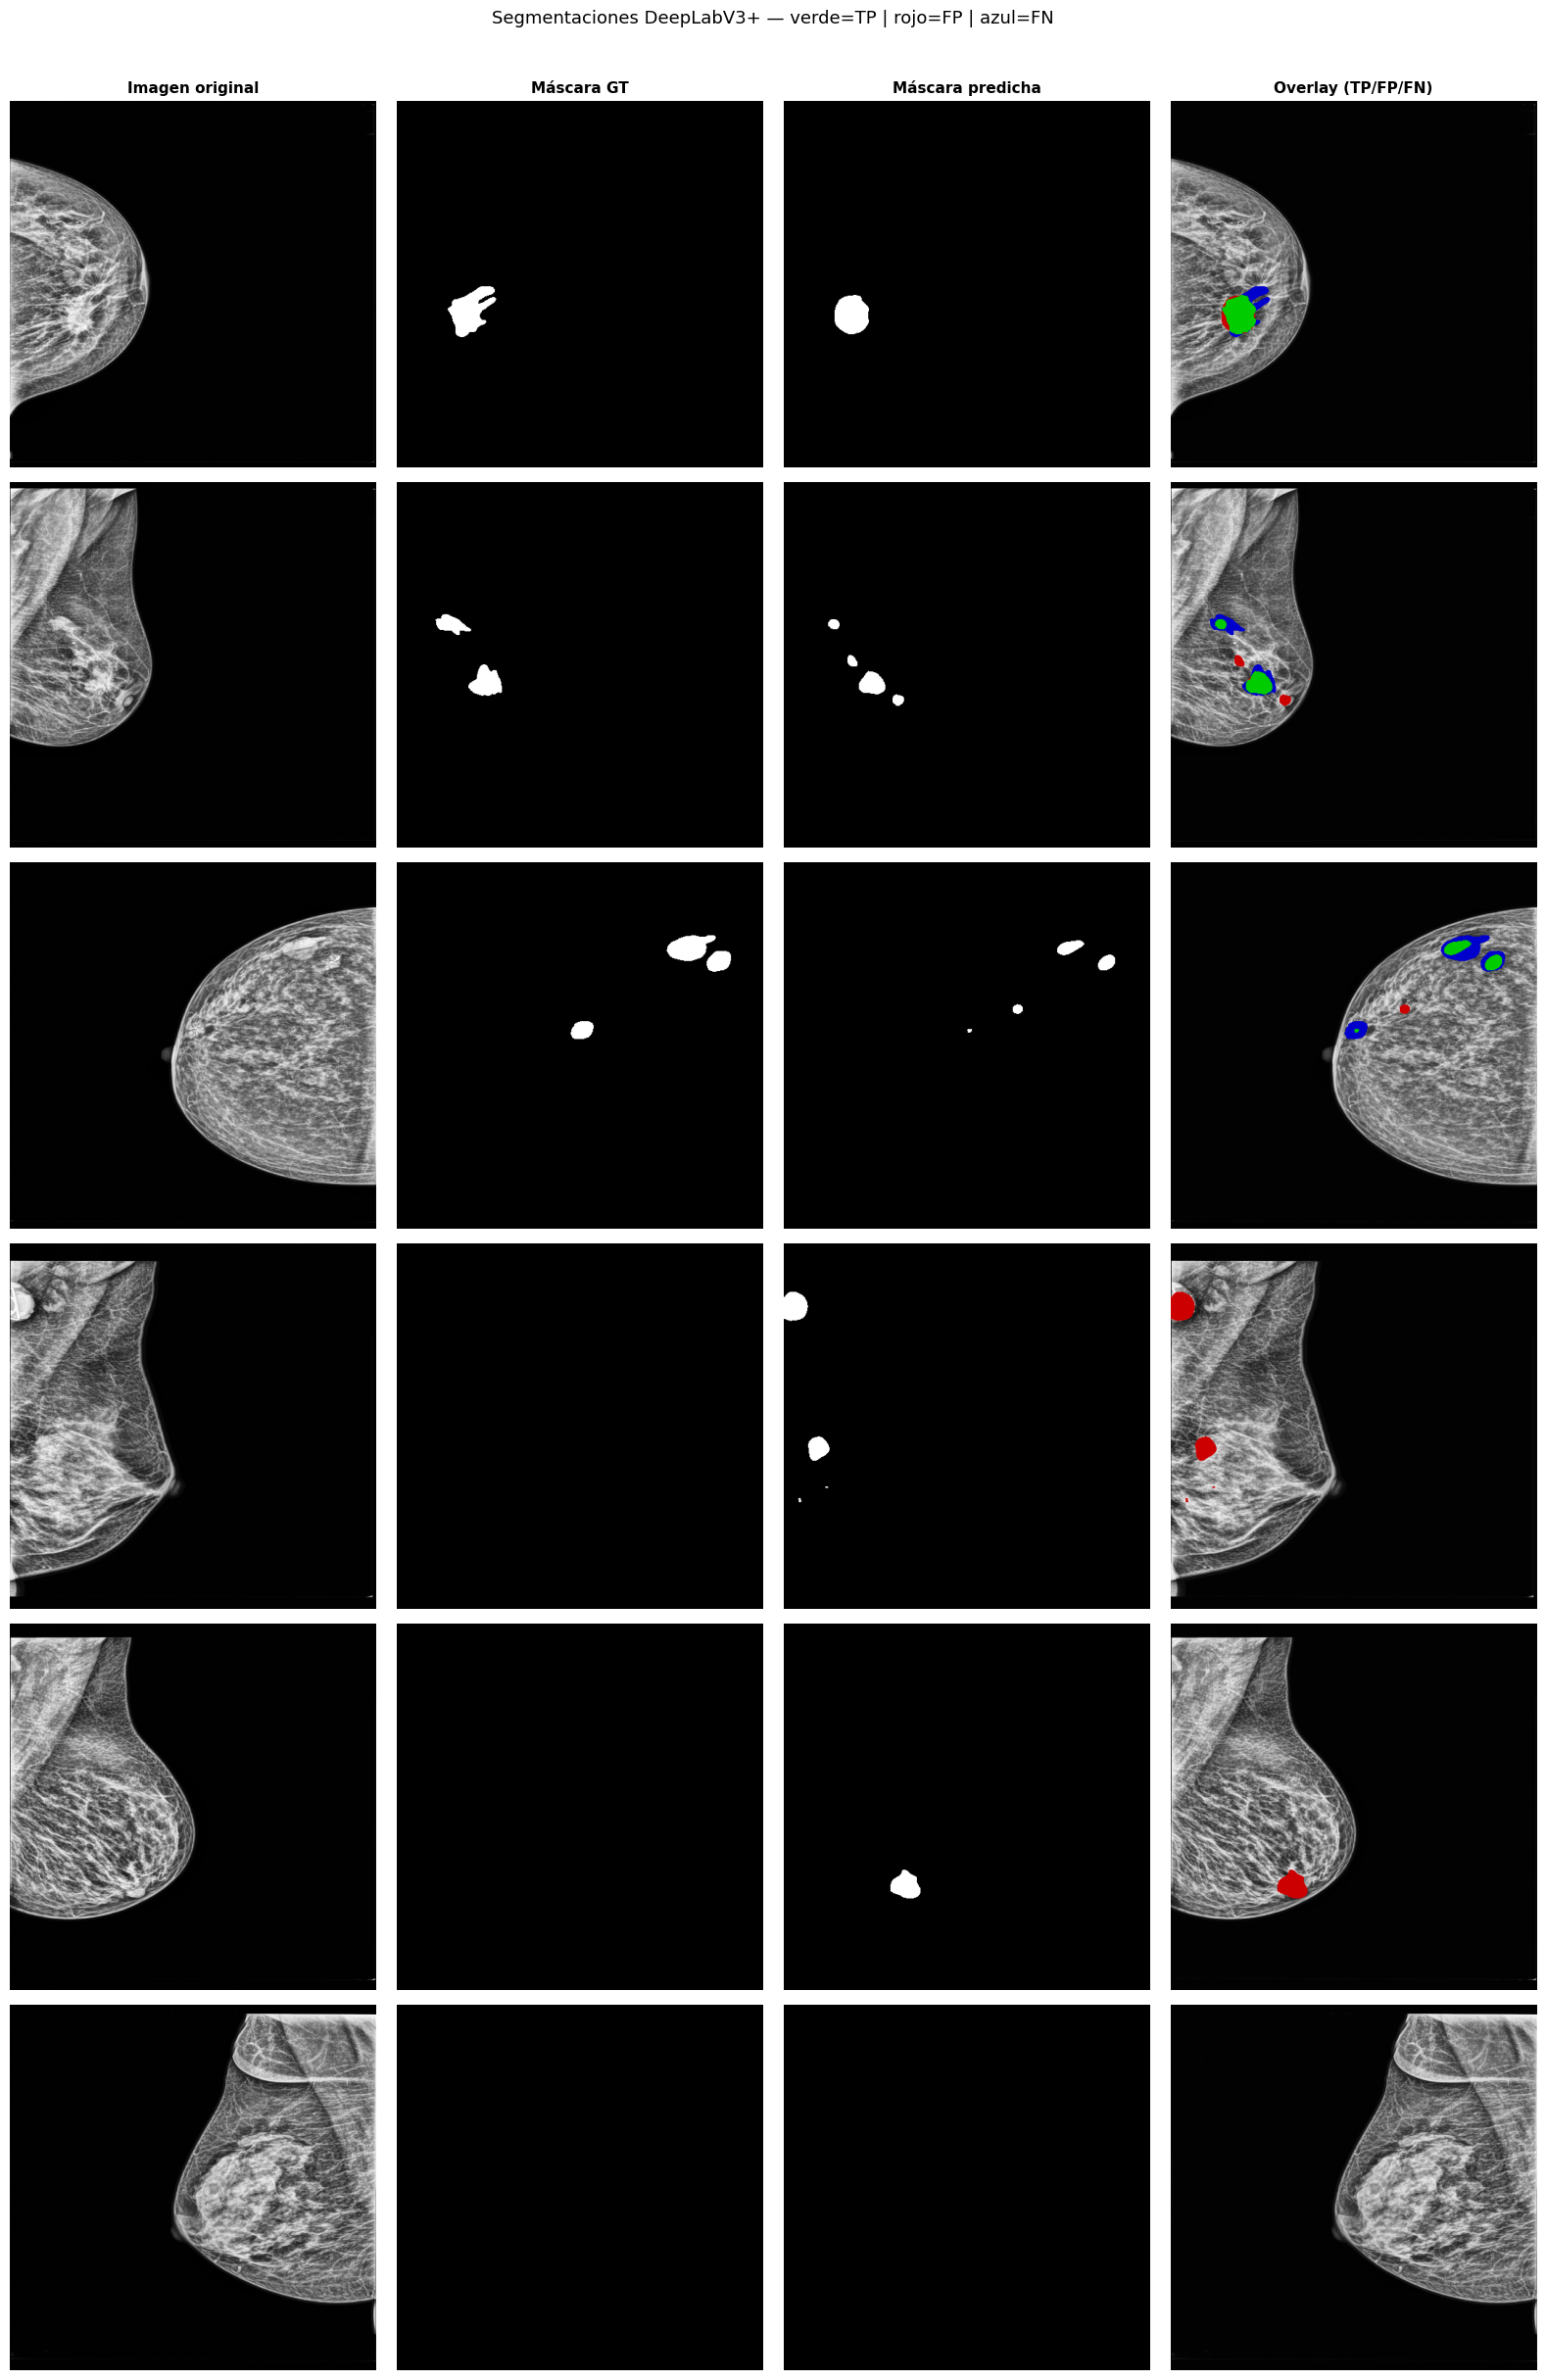

In [11]:
def denormalize(tensor):
    """Desnormaliza un tensor (3, H, W) a imagen [0, 1] RGB."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


@torch.no_grad()
def visualize_segmentations(model, dataset, device, n=6):
    """
    Muestra n ejemplos: imagen original | máscara GT | máscara predicha | overlay.
    Verde = verdadero positivo | Rojo = falso positivo | Azul = falso negativo.
    """
    indices = np.random.choice(len(dataset), n, replace=False)
    fig, axes = plt.subplots(n, 4, figsize=(16, n * 4))
    col_titles = ['Imagen original', 'Máscara GT', 'Máscara predicha', 'Overlay (TP/FP/FN)']

    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=11, fontweight='bold')

    for row, idx in enumerate(indices):
        img_t, mask_t = dataset[idx]
        logit = model(img_t.unsqueeze(0).to(device))
        pred  = (torch.sigmoid(logit) > 0.5).squeeze().cpu().numpy().astype(np.uint8)
        gt    = mask_t.squeeze().numpy().astype(np.uint8)
        img_np = denormalize(img_t).permute(1, 2, 0).numpy()[:, :, 0]

        # Dice por muestra
        sample_dice = dice_coefficient(pred, gt)

        # Overlay: TP=verde, FP=rojo, FN=azul
        overlay = np.stack([img_np, img_np, img_np], axis=2)
        tp = (pred == 1) & (gt == 1)
        fp = (pred == 1) & (gt == 0)
        fn = (pred == 0) & (gt == 1)
        overlay[tp] = [0.0, 0.8, 0.0]  # verde
        overlay[fp] = [0.8, 0.0, 0.0]  # rojo
        overlay[fn] = [0.0, 0.0, 0.8]  # azul

        axes[row, 0].imshow(img_np, cmap='gray')
        axes[row, 1].imshow(gt,    cmap='gray')
        axes[row, 2].imshow(pred,  cmap='gray')
        axes[row, 3].imshow(overlay)
        axes[row, 0].set_ylabel(f'Dice={sample_dice:.3f}', fontsize=9)
        for ax in axes[row]:
            ax.axis('off')

    plt.suptitle(
        'Segmentaciones DeepLabV3+ — verde=TP | rojo=FP | azul=FN',
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.show()


test_dataset = SegmentationDataset(df_test, augment=False)
visualize_segmentations(best_model, test_dataset, DEVICE)

El análisis visual de las seis muestras seleccionadas aleatoriamente del conjunto de test permite extraer conclusiones relevantes sobre el comportamiento del modelo DeepLabV3+, complementando las métricas globales y permitiendo identificar sus principales fortalezas y debilidades diagnósticas.

En las filas primera, tercera y cuarta se observan los mejores resultados, con coeficientes Dice individuales de 0.781, 0.787 y 0.751, respectivamente. En las imágenes de overlay, predomina claramente el color verde (verdaderos positivos), lo que indica que el modelo ha localizado correctamente el núcleo principal de la lesión y ha delineado sus contornos con gran proximidad a la máscara real (Ground Truth). En estos casos, los errores de sobresegmentación (rojo) y subsegmentación (azul) son mínimos y se concentran principalmente en las irregularidades de los bordes de la lesión.

Por el contrario, la segunda fila representa uno de los escenarios más críticos en el contexto clínico: el falso negativo. Con un Dice de 0.000, el modelo no es capaz de detectar la lesión. En el overlay, la región aparece completamente en azul (falsos negativos), mientras que la máscara predicha es totalmente negra. Visualmente, se observa que la lesión se encuentra en una zona de alta densidad mamaria, caracterizada por mayor brillo y variabilidad del tejido circundante. Esto sugiere que el modelo presenta dificultades para discriminar estructuras patológicas en entornos de bajo contraste o alta complejidad textural.

La quinta fila muestra un coeficiente Dice bajo de 0.252, asociado a un fenómeno de sobresegmentación masiva. Aunque el modelo logra identificar parcialmente la lesión (zona verde), extiende la predicción de forma incorrecta hacia tejido sano adyacente, generando una amplia región de falsos positivos (rojo). Este comportamiento suele aparecer cuando los bordes de la lesión son difusos o cuando el modelo confunde tejido fibroglandular normal con tejido patológico, priorizando la sensibilidad a costa de una menor especificidad.

La última fila también presenta un Dice de 0.000, pero en este caso debido al tamaño extremadamente reducido de la lesión, que ocupa apenas unos pocos píxeles en la máscara de referencia. El modelo no activa ninguna predicción en esta región. Este resultado pone de manifiesto la pérdida de resolución espacial del modelo o las limitaciones de los módulos de convolución dilatada (ASPP) para preservar estructuras de escala muy pequeña tras las sucesivas reducciones espaciales del encoder.

En conjunto, la inspección cualitativa confirma que, cuando el modelo detecta lesiones en regiones de contraste relativamente alto, es capaz de producir segmentaciones precisas y morfológicamente coherentes (Dice ≈ 0.78). Sin embargo, el rendimiento global (Dice ≈ 0.50) se ve considerablemente afectado por dos factores principales: la omisión completa de lesiones pequeñas o de bajo contraste, y la tendencia a la sobresegmentación en tejidos densos.

Para mitigar estas limitaciones, sería recomendable incorporar funciones de pérdida más sensibles a estructuras pequeñas o bordes, así como mecanismos de atención (Attention Gates) que permitan al modelo enfocarse de forma más efectiva en regiones de menor tamaño o menor contraste.

### **12. Análisis de métricas por clase diagnóstica**

Este código evalúa el rendimiento de un modelo de segmentación (DeepLabV3+) calculando las métricas Dice e IoU por clase diagnóstica en el conjunto de test.

Primero, el modelo se pone en modo evaluación y se desactivan los gradientes para acelerar la inferencia. Luego, se utiliza un DataLoader para procesar las imágenes en lotes y obtener las predicciones del modelo, que se binarizan con un umbral de 0.5. Estas predicciones se comparan con las máscaras reales.

Después, para cada muestra se calculan las métricas Dice e IoU, y los resultados se agrupan por clase diagnóstica, obteniendo la media y la desviación estándar de cada métrica.

Finalmente, se genera un gráfico de barras que muestra el rendimiento medio por clase, junto con su variabilidad, lo que permite comparar el desempeño del modelo entre diferentes tipos de lesiones de forma visual y clara.

Métricas por clase diagnóstica (Test):
              dice             iou        
              mean     std    mean     std
class_name                                
Benigno     0.5209  0.3443  0.4209  0.3134
Maligno     0.5679  0.2966  0.4493  0.2701
NORM        0.4021  0.4937  0.4000  0.4954


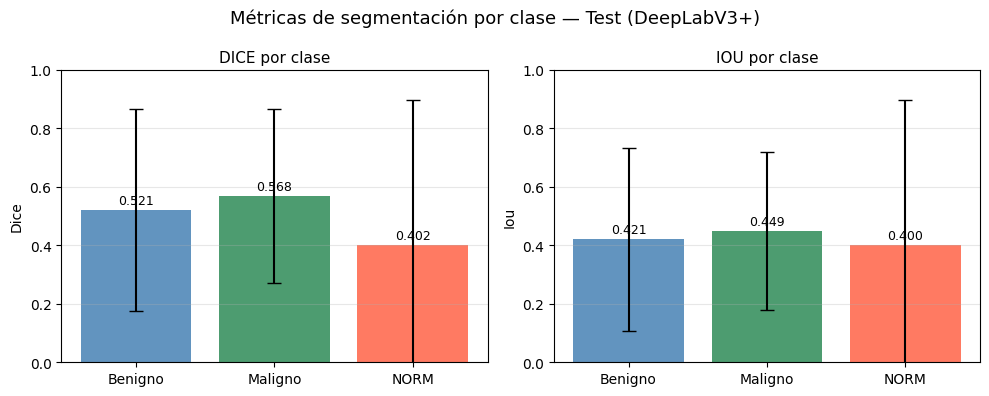

In [12]:
@torch.no_grad()
def metrics_by_class(model, df: pd.DataFrame, device):
    """
    Calcula Dice e IoU por clase diagnóstica usando DataLoader completo.
    Mucho más rápido que crear un Dataset por fila (evita overhead de
    inicialización y hace inferencia en batches).
    """
    model.eval()
    loader = DataLoader(
        SegmentationDataset(df.reset_index(drop=True), augment=False),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
    )
    all_preds, all_masks = [], []
    for imgs, masks in tqdm(loader, desc='metrics_by_class', leave=False):
        logits = model(imgs.to(device))
        preds  = (torch.sigmoid(logits) > 0.5).cpu().numpy().astype(np.uint8)
        all_preds.append(preds)
        all_masks.append(masks.numpy().astype(np.uint8))

    all_preds = np.concatenate(all_preds, axis=0)  # (N, 1, H, W)
    all_masks = np.concatenate(all_masks, axis=0)

    results = []
    for i, row in enumerate(df.reset_index(drop=True).itertuples()):
        dice = dice_coefficient(all_preds[i].flatten(), all_masks[i].flatten())
        iou  = jaccard_score(all_masks[i].flatten(), all_preds[i].flatten(), zero_division=1)
        results.append({'label': row.label, 'dice': dice, 'iou': iou})

    df_res = pd.DataFrame(results)
    df_res['class_name'] = df_res['label'].map(dict(enumerate(CLASS_NAMES)))
    return df_res.groupby('class_name')[['dice', 'iou']].agg(['mean', 'std'])


summary = metrics_by_class(best_model, df_test, DEVICE)
print('Métricas por clase diagnóstica (Test):')
print(summary.round(4))

# Gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric in zip(axes, ['dice', 'iou']):
    means = summary[metric]['mean']
    stds  = summary[metric]['std']
    bars  = ax.bar(means.index, means.values, yerr=stds.values,
                   color=['steelblue', 'seagreen', 'tomato'], capsize=5, alpha=0.85)
    ax.set_ylim(0, 1.0)
    ax.set_title(f'{metric.upper()} por clase', fontsize=11)
    ax.set_ylabel(metric.capitalize()); ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Métricas de segmentación por clase — Test (DeepLabV3+)', fontsize=13)
plt.tight_layout()
plt.show()

El desglose de las métricas de test según la patología subyacente revela patrones de comportamiento asimétricos altamente informativos sobre el aprendizaje del modelo.

En la clase Maligno (Dice: $0.5679 \pm 0.2966$ / IoU: $0.4493 \pm 0.2701$), se obtiene el mejor rendimiento promedio. Esto puede explicarse porque los tumores malignos suelen presentar mayor tamaño, contraste elevado y distorsiones estructurales evidentes en las mamografías, lo que facilita su segmentación. Sin embargo, la alta desviación estándar indica dificultades en la delimitación de bordes infiltrantes o espiculados.

En la clase Benigno (Dice: $0.5209 \pm 0.3443$ / IoU: $0.4209 \pm 0.3134$), el rendimiento disminuye ligeramente. Aunque estas lesiones suelen tener contornos definidos, con frecuencia son de pequeño tamaño (quistes, fibroadenomas o microcalcificaciones), lo que afecta negativamente al modelo debido a la pérdida de resolución en el encoder. Esto genera una alta variabilidad en los resultados.

En la clase Normal (NORM) (Dice: $0.4021 \pm 0.4937$ / IoU: $0.4000 \pm 0.4954$), los resultados requieren una interpretación especial, ya que no existen lesiones. En estos casos, una predicción perfecta debería corresponder a un Dice de 1.0, pero debido a la implementación de las métricas (manejo de casos vacíos con zero_division=1), el comportamiento del modelo se vuelve binario: aciertos completos o falsos positivos. Esto explica la media baja y la desviación estándar extremadamente alta, reflejando una fuerte inestabilidad.

Conclusión, el modelo es capaz de detectar adecuadamente masas malignas, pero muestra limitaciones en lesiones benignas pequeñas y, sobre todo, una baja especificidad en casos normales, generando falsos positivos frecuentes. Esto sugiere la necesidad de incorporar estrategias como un clasificador previo o funciones de pérdida que penalicen más fuertemente las activaciones en imágenes normales.

### **13. Mapa de probabilidad (heatmap de confianza)**

Este último código visualiza de forma cualitativa el comportamiento del modelo de segmentación DeepLabV3+ mostrando mapas de probabilidad por píxel sobre un conjunto de imágenes de test.

En primer lugar, se seleccionan aleatoriamente n imágenes del dataset. Para cada una de ellas, el modelo realiza una predicción en modo evaluación (@torch.no_grad()), generando un mapa de logits que posteriormente se transforma en probabilidades mediante la función sigmoide. Estas probabilidades representan la confianza del modelo en que cada píxel pertenezca a una lesión.

A continuación, se construye una figura comparativa con tres columnas: la imagen original, la máscara real (ground truth) y el mapa de probabilidad generado por el modelo. La imagen original se muestra en escala de grises, la máscara GT permite visualizar la segmentación real, y el mapa de probabilidad se representa con un colormap tipo hot, donde los valores cercanos a 1 indican alta probabilidad de lesión y los valores cercanos a 0 corresponden a tejido sano. Además, se incluye una barra de color para interpretar cuantitativamente las probabilidades.

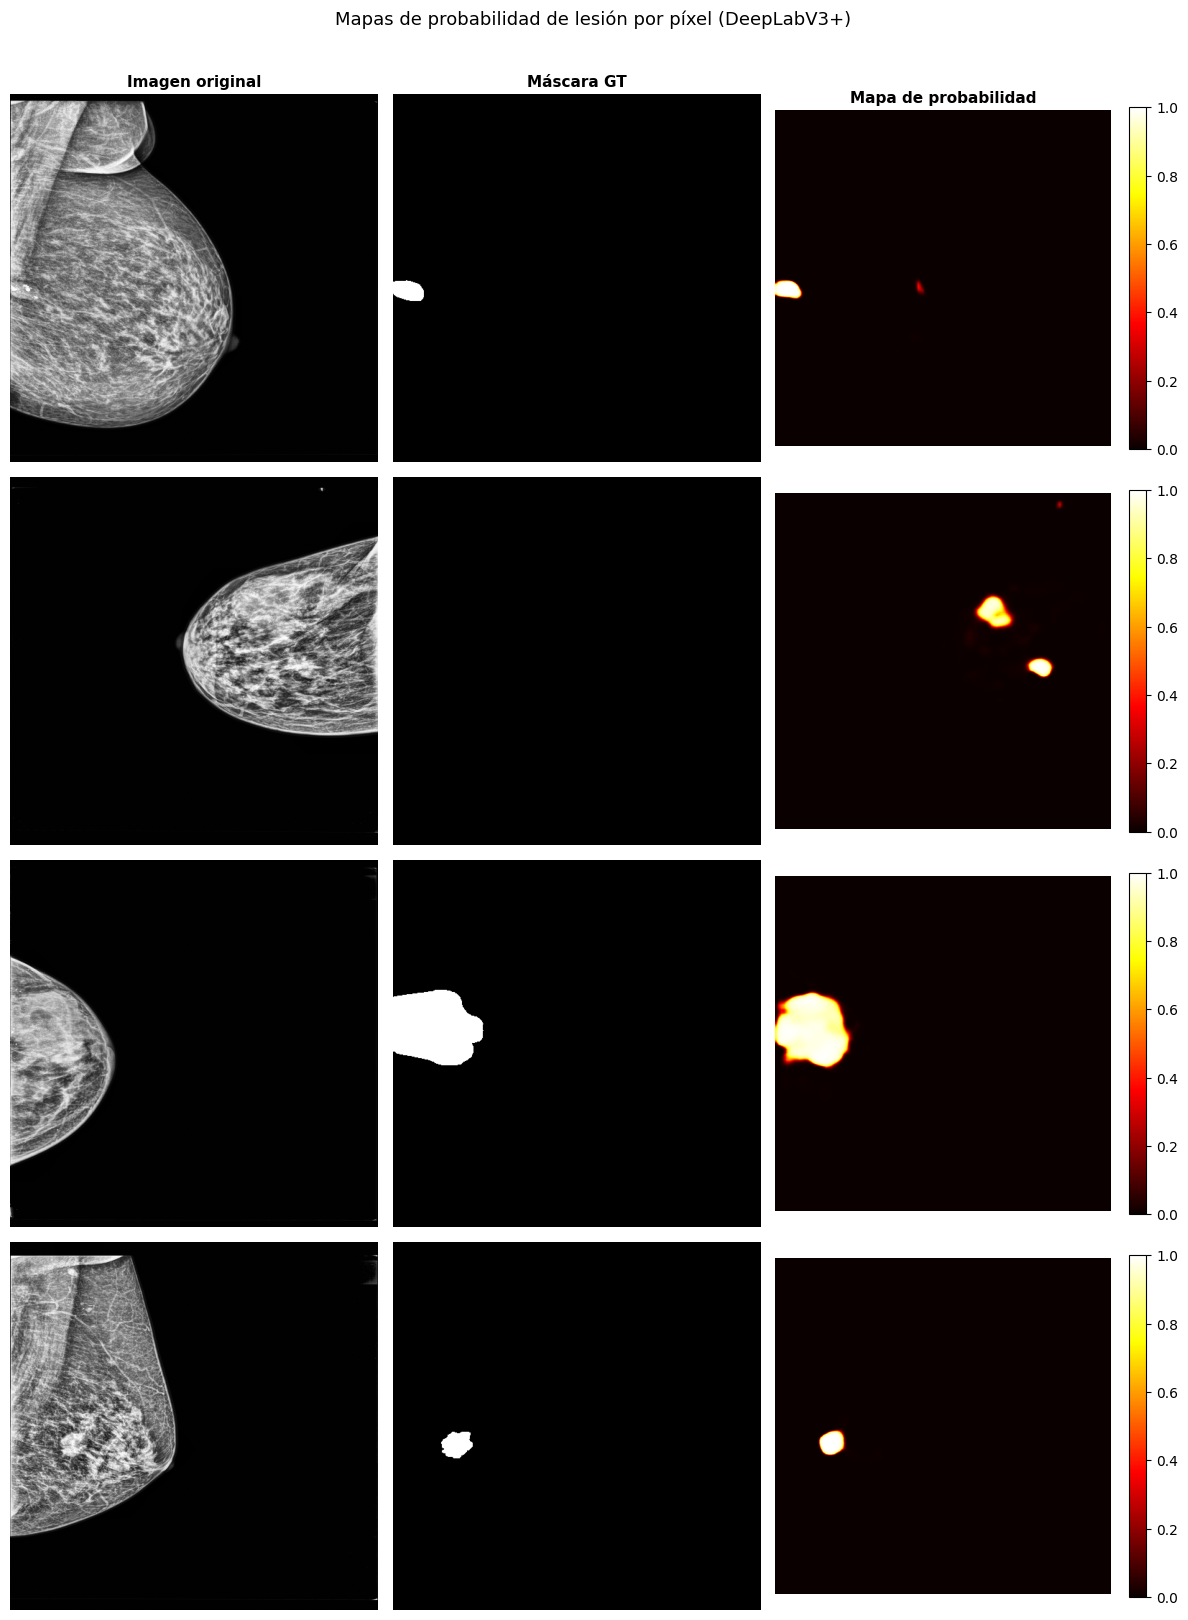

In [13]:
@torch.no_grad()
def show_probability_maps(model, dataset, device, n=4):
    indices = np.random.choice(len(dataset), n, replace=False)
    fig, axes = plt.subplots(n, 3, figsize=(12, n * 4))
    col_titles = ['Imagen original', 'Máscara GT', 'Mapa de probabilidad']

    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=11, fontweight='bold')

    for row, idx in enumerate(indices):
        img_t, mask_t = dataset[idx]
        logit    = model(img_t.unsqueeze(0).to(device))
        prob_map = torch.sigmoid(logit).squeeze().cpu().numpy()
        gt       = mask_t.squeeze().numpy()
        img_np   = denormalize(img_t).permute(1, 2, 0).numpy()[:, :, 0]

        axes[row, 0].imshow(img_np,   cmap='gray')
        axes[row, 1].imshow(gt,       cmap='gray')
        im = axes[row, 2].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
        plt.colorbar(im, ax=axes[row, 2], fraction=0.046)
        for ax in axes[row]:
            ax.axis('off')

    plt.suptitle('Mapas de probabilidad de lesión por píxel (DeepLabV3+)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


show_probability_maps(best_model, test_dataset, DEVICE)

La inspección visual de las cuatro muestras de test permite extraer conclusiones relevantes sobre la confianza predictiva del modelo y el comportamiento de sus activaciones espaciales.

La primera fila corresponde al caso más favorable. Ante una lesión claramente delimitada en la máscara de referencia, el mapa de probabilidad muestra una activación muy focalizada. El centro de la lesión alcanza valores cercanos a 1.0 (tonos blanco/amarillo), mientras que los bordes descienden rápidamente hacia valores próximos a 0. La ausencia de activaciones dispersas en el resto de la imagen indica que, en lesiones bien contrastadas, el modelo opera con alta seguridad y una segmentación estable.

En la segunda fila, la máscara real no contiene lesiones, pero el mapa de probabilidad presenta una activación localizada en la región superior izquierda. Esta zona aparece con valores intermedios (aprox. 0.4–0.6, en tonos rojizos/anaranjados suaves), lo que sugiere una predicción incierta más que una detección firme. Este comportamiento suele estar relacionado con confusiones con estructuras anatómicas de alta densidad o brillo, como el músculo pectoral.

La tercera fila muestra una lesión de mayor tamaño correctamente identificada en su región central, donde el modelo alcanza alta confianza. Sin embargo, los bordes presentan una transición progresiva de colores hacia tonos rojos y naranjas, reflejando incertidumbre en la delimitación periférica. Esto indica que, aunque el núcleo de la lesión está bien aprendido, las regiones marginales no se segmentan con precisión, lo que puede afectar métricas como IoU al aplicar umbrales rígidos.

En la última fila, el Ground Truth contiene una lesión pequeña, pero el mapa de probabilidad no muestra activaciones relevantes, manteniéndose completamente en valores cercanos a 0. Esto evidencia una omisión total de la lesión, lo que apunta a una limitación del modelo para capturar estructuras de muy pequeño tamaño o bajo contraste.

En general, los mapas de probabilidad muestran un comportamiento bastante binario: cuando el modelo detecta correctamente la lesión, lo hace con alta confianza y buena focalización, pero cuando falla, lo hace mediante incertidumbre en bordes o ausencia total de activación. Esto sugiere que el rendimiento podría mejorar ajustando el umbral de decisión de forma más óptima (por ejemplo, mediante curvas ROC o PR) en lugar de utilizar un valor fijo de 0.5, especialmente en un problema tan sensible como la segmentación médica.

### **14. Guardado de resultados para evaluación comparativa**

In [14]:
# Guardar máscaras predichas y ground-truth
np.save(RESULTS_DIR / 'deeplab_test_preds.npy', test_preds)  # (N, 1, H, W) binario
np.save(RESULTS_DIR / 'deeplab_test_masks.npy', test_masks)  # (N, 1, H, W) binario

# Guardar métricas por muestra en CSV
per_sample_dice = [
    dice_coefficient(test_preds[i].flatten(), test_masks[i].flatten())
    for i in range(len(test_preds))
]
per_sample_iou = [
    jaccard_score(test_masks[i].flatten(), test_preds[i].flatten(), zero_division=1)
    for i in range(len(test_preds))
]

pd.DataFrame({
    'image_id':  df_test['image_id'].values,
    'label':     df_test['label'].values,
    'dice':      per_sample_dice,
    'iou':       per_sample_iou,
}).to_csv(RESULTS_DIR / 'deeplab_predictions.csv', index=False)

# Guardar resumen K-Fold
df_kfold.to_csv(RESULTS_DIR / 'deeplab_kfold_summary.csv', index=False)

# Guardar métricas globales
pd.DataFrame([{
    'test_loss': test_loss,
    'test_dice': test_dice,
    'test_iou':  test_iou,
    'pixel_acc': pixel_acc,
}]).to_csv(RESULTS_DIR / 'deeplab_test_metrics.csv', index=False)

print('Guardado en', RESULTS_DIR)
print('  deeplab_test_preds.npy / deeplab_test_masks.npy')
print('  deeplab_predictions.csv')
print('  deeplab_kfold_summary.csv')
print('  deeplab_test_metrics.csv')

Guardado en /kaggle/working/results
  deeplab_test_preds.npy / deeplab_test_masks.npy
  deeplab_predictions.csv
  deeplab_kfold_summary.csv
  deeplab_test_metrics.csv
